# Ensemble — LOF + IF (AND rule)
A point is anomalous only when both models agree. Reduces false alarms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix

## Load data and split

In [2]:
data = pd.read_csv('../data/labeled.csv', parse_dates=['timestamp'])
split_point = int(len(data) * 0.8)
train_data = data.iloc[:split_point]
test_data = data.iloc[split_point:]

feature_columns = ['memory_pct', 'roll_mean_1h', 'roll_std_1h', 'roll_mean_24h',
                   'diff_1', 'diff_6', 'hour', 'minute', 'time_of_day', 'day_of_week', 'is_weekend']

X_train = train_data[feature_columns].values
X_test = test_data[feature_columns].values
y_test = test_data['label'].values

## Train both models

In [3]:
lof_model = LocalOutlierFactor(n_neighbors=50, contamination=0.005, novelty=True)
lof_model.fit(X_train)
lof_predictions = (lof_model.predict(X_test) == -1).astype(int)

isolation_forest = IsolationForest(n_estimators=200, contamination=0.013, random_state=42)
isolation_forest.fit(X_train)
isolation_predictions = (isolation_forest.predict(X_test) == -1).astype(int)

print('LOF flagged:', lof_predictions.sum())
print('IF flagged:', isolation_predictions.sum())

LOF flagged: 52
IF flagged: 66


## Combine using AND rule (both models must agree)

In [4]:
ensemble_predictions = ((lof_predictions == 1) & (isolation_predictions == 1)).astype(int)
print('Ensemble flagged (both agreed):', ensemble_predictions.sum())

Ensemble flagged (both agreed): 13


## Plot detections

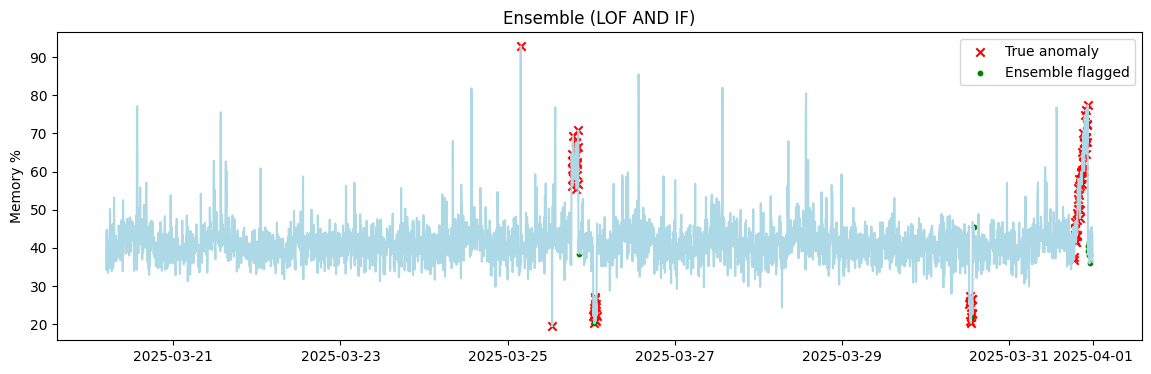

In [5]:
timestamps = test_data['timestamp'].values
memory = test_data['memory_pct'].values

plt.figure(figsize=(14, 4))
plt.plot(timestamps, memory, color='lightblue')
plt.scatter(timestamps[y_test == 1], memory[y_test == 1], color='red', marker='x', label='True anomaly')
plt.scatter(timestamps[ensemble_predictions == 1], memory[ensemble_predictions == 1], color='green', s=10, label='Ensemble flagged')
plt.title('Ensemble (LOF AND IF)')
plt.ylabel('Memory %')
plt.legend()
plt.show()

## Evaluation

In [6]:
print(classification_report(y_test, ensemble_predictions, target_names=['Normal','Anomaly'], zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, ensemble_predictions))

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98      3301
     Anomaly       0.31      0.04      0.07        98

    accuracy                           0.97      3399
   macro avg       0.64      0.52      0.53      3399
weighted avg       0.95      0.97      0.96      3399

Confusion matrix:
[[3292    9]
 [  94    4]]
